## EXPERIMENT 4: Image Classification using Neural Network with R + Keras 3

### 1. Install Packages

In [16]:
install.packages(c("jpeg", "keras3"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



### 2. Load Packages

In [17]:
library(jpeg)
library(keras3)

### 3. Read Images

In [18]:
# In Google Colab, images should be in:
# /content/sample_data/images

setwd("/content/sample_data")

# Install packages if needed
if (!requireNamespace("jpeg", quietly = TRUE)) {
  install.packages("jpeg")
}

if (!requireNamespace("png", quietly = TRUE)) {
  install.packages("png")
}

library(jpeg)
library(png)

# Image files
pics <- c(
  "p1.jpg", "p2.jpg", "p3.jpg",
  "p4.jpg", "p5.jpg", "p6.jpg",
  "c1.jpg", "c2.jpg", "c3.jpg",
  "c4.jpg", "c5.jpg", "c6.jpg"
)

# Function to detect the REAL image format
read_image <- function(file) {
  # Read first few bytes of the file
  con <- file(file, "rb")
  bytes <- readBin(con, "raw", n = 8)
  close(con)

  # Convert bytes to hexadecimal
  hex <- paste(sprintf("%02X", as.integer(bytes)), collapse = "")

  # PNG signature: 89504E47
  if (startsWith(hex, "89504E47")) {
    message("PNG detected: ", file)
    return(readPNG(file))
  }

  # JPEG signature: FFD8FF
  if (startsWith(hex, "FFD8FF")) {
    message("JPEG detected: ", file)
    return(readJPEG(file))
  }

  stop(paste("Unknown image format:", file))
}

# Empty list
mypic <- list()

# Read all images and STRIP alpha channel
for (i in seq_along(pics)) {
  img <- read_image(pics[i])

  # FIX: If image has 4 channels (RGBA), keep only the first 3 (RGB)
  if (length(dim(img)) == 3 && dim(img)[3] == 4) {
    img <- img[, , 1:3]
  }

  mypic[[i]] <- img
}

# Check how many images were loaded
length(mypic)

JPEG detected: p1.jpg

JPEG detected: p2.jpg

PNG detected: p3.jpg

PNG detected: p4.jpg

PNG detected: p5.jpg

JPEG detected: p6.jpg

JPEG detected: c1.jpg

JPEG detected: c2.jpg

JPEG detected: c3.jpg

JPEG detected: c4.jpg

JPEG detected: c5.jpg

PNG detected: c6.jpg



[1] 12

### 4. Explore Images

, , 1

             [,1]      [,2]      [,3]      [,4]      [,5]      [,6]      [,7]
   [1,] 0.5176471 0.5215686 0.5254902 0.5294118 0.5294118 0.5254902 0.5254902
   [2,] 0.5215686 0.5215686 0.5294118 0.5294118 0.5294118 0.5294118 0.5254902
   [3,] 0.5215686 0.5254902 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118
   [4,] 0.5254902 0.5254902 0.5333333 0.5333333 0.5333333 0.5333333 0.5294118
   [5,] 0.5254902 0.5294118 0.5333333 0.5372549 0.5372549 0.5333333 0.5333333
   [6,] 0.5294118 0.5294118 0.5372549 0.5372549 0.5372549 0.5372549 0.5333333
   [7,] 0.5333333 0.5333333 0.5372549 0.5411765 0.5411765 0.5372549 0.5372549
   [8,] 0.5333333 0.5333333 0.5411765 0.5411765 0.5411765 0.5411765 0.5372549
   [9,] 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118 0.5333333
  [10,] 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118 0.5333333
  [11,] 0.5333333 0.5294118 0.5333333 0.5294118 0.5294118 0.5333333 0.5333333
  [12,] 0.5333333 0.5333333 0.5333333 0.5333333 0.5333333

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.6039  0.6471  0.6311  0.7255  1.0000 

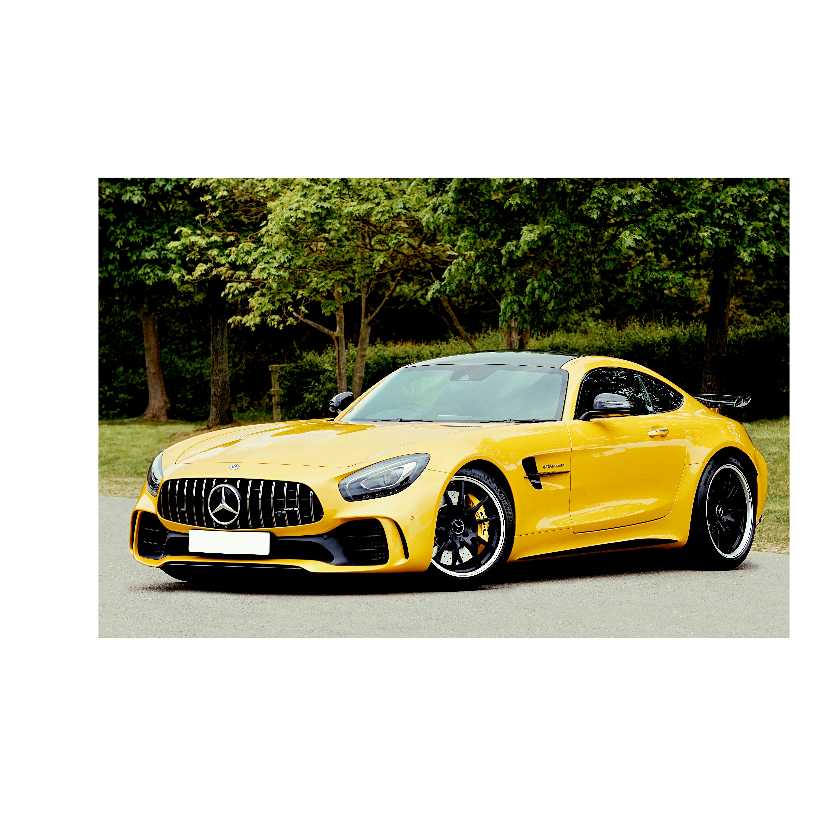

List of 12
 $ : num [1:3456, 1:5184, 1:3] 0.518 0.522 0.522 0.525 0.525 ...
 $ : num [1:700, 1:1050, 1:3] 0.188 0.188 0.188 0.188 0.188 ...
 $ : num [1:1131, 1:1697, 1:3] 0 0 0 0 0 0 0 0 0 0 ...
 $ : num [1:1200, 1:1920, 1:3] 0 0 0 0 0 0 0 0 0 0 ...
 $ : num [1:2291, 1:4392, 1:3] 1 1 1 1 1 1 1 1 1 1 ...
 $ : num [1:1333, 1:2000, 1:3] 0.467 0.471 0.463 0.459 0.463 ...
 $ : num [1:3632, 1:5456, 1:3] 0.894 0.894 0.894 0.894 0.894 ...
 $ : num [1:3632, 1:5456, 1:3] 0 0 0 0 0 0 0 0 0 0 ...
 $ : num [1:3264, 1:4912, 1:3] 0.318 0.31 0.298 0.29 0.282 ...
 $ : num [1:1125, 1:2000, 1:3] 0.424 0.416 0.408 0.349 0.333 ...
 $ : num [1:2995, 1:5472, 1:3] 0.169 0.165 0.165 0.161 0.161 ...
 $ : num [1:1078, 1:2084, 1:3] 1 1 1 1 1 1 1 1 1 1 ...


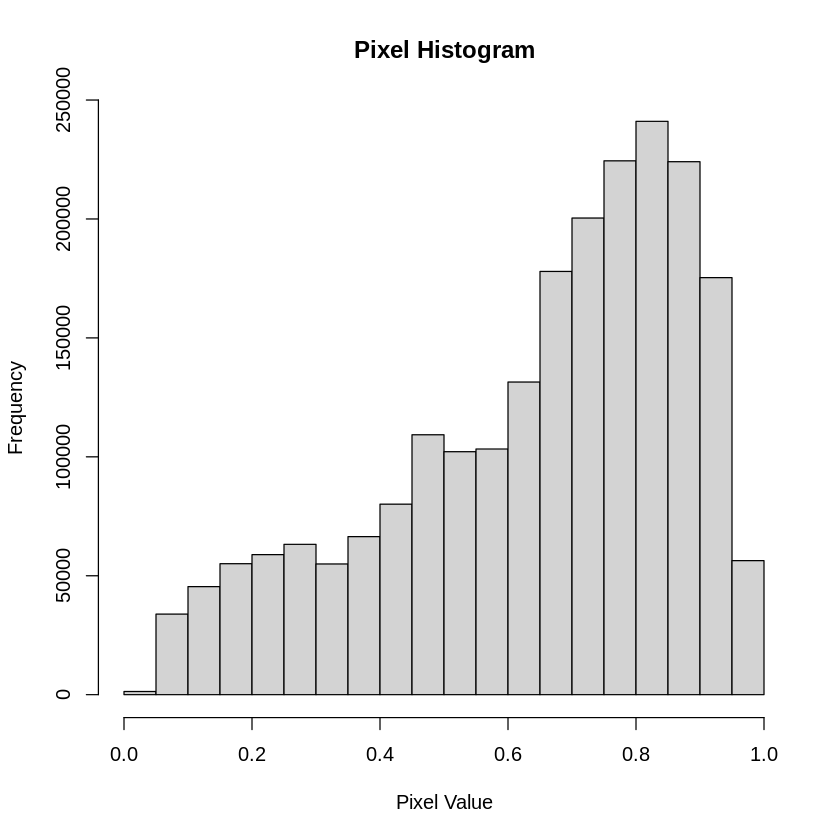

In [19]:
print(mypic[[1]])

# Display image
plot(
  as.raster(mypic[[8]]),
  main = "Image 8"
)

# Summary
summary(mypic[[1]])

# Histogram
hist(
  as.numeric(mypic[[2]]),
  main = "Pixel Histogram",
  xlab = "Pixel Value"
)

# Structure
str(mypic)

### 5. Resize Images to 28 x 28

In [20]:
# Simple nearest-neighbor resize using base R

resize_image <- function(img, width = 28, height = 28) {

  old_height <- dim(img)[1]
  old_width  <- dim(img)[2]

  row_index <- round(
    seq(1, old_height, length.out = height)
  )

  col_index <- round(
    seq(1, old_width, length.out = width)
  )

  row_index[row_index < 1] <- 1
  col_index[col_index < 1] <- 1

  resized <- img[row_index, col_index, , drop = FALSE]

  return(resized)
}


for (i in 1:12) {

  mypic[[i]] <- resize_image(
    mypic[[i]],
    28,
    28
  )

}


# Check dimensions

for (i in 1:12) {
  print(dim(mypic[[i]]))
}

[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3


### 6. Convert Images to Vectors

In [21]:
# 28 x 28 x 3 = 2352 features

image_to_vector <- function(img) {
  as.numeric(img)
}

### 7. Create Training Data

In [22]:
# Original experiment:
# images 1-5 and 7-11 = training (10 images total)
# images 6 and 12 = testing (2 images total)

trainx <- NULL

# FIX: Loop through both sets of training images to match the 10 labels in trainy
for (i in c(1:5, 7:11)) {
  trainx <- rbind(
    trainx,
    image_to_vector(mypic[[i]])
  )
}

testx <- rbind(
  image_to_vector(mypic[[6]]),
  image_to_vector(mypic[[12]])
)

### 8. Create Labels

In [23]:
trainy <- c(
  0, 0, 0, 0, 0,
  1, 1, 1, 1, 1
)

testy <- c(
  0, 1
)

### Check Dimensions

In [24]:
print(dim(trainx))
print(dim(testx))

print(trainy)
print(testy)

[1]   10 2352
[1]    2 2352
 [1] 0 0 0 0 0 1 1 1 1 1
[1] 0 1


### 9. One-Hot Encoding

In [25]:
# Avoid to_categorical()
# Use base R instead

trainLabels <- cbind(
  as.numeric(trainy == 0),
  as.numeric(trainy == 1)
)

testLabels <- cbind(
  as.numeric(testy == 0),
  as.numeric(testy == 1)
)

print(trainLabels)
print(testLabels)

      [,1] [,2]
 [1,]    1    0
 [2,]    1    0
 [3,]    1    0
 [4,]    1    0
 [5,]    1    0
 [6,]    0    1
 [7,]    0    1
 [8,]    0    1
 [9,]    0    1
[10,]    0    1
     [,1] [,2]
[1,]    1    0
[2,]    0    1


### 10. Build Neural Network

In [26]:
model <- keras_model_sequential(
  input_shape = c(2352)
) |>
  layer_dense(
    units = 256,
    activation = "relu"
  ) |>
  layer_dense(
    units = 128,
    activation = "relu"
  ) |>
  layer_dense(
    units = 2,
    activation = "softmax"
  )


# Display model

summary(model)

Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                   │ (None, 256)              │       602,368 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_4 (Dense)                   │ (None, 128)              │        32,896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_5 (Dense)                   │ (None, 2)                │           258 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘
 Total params: 635,522 (2.42 MB)
 Trainable params: 635,522 (2.42 MB)
 Non-trainable params: 0 (0.00 B)


### 11. Compile Model

In [27]:
compile(
  model,

  optimizer = optimizer_adam(),

  loss = "categorical_crossentropy",

  metrics = c("accuracy")
)

### 12. Train Model

In [28]:
history <- fit(
  model,

  trainx,

  trainLabels,

  epochs = 30,

  batch_size = 2,

  validation_split = 0.2
)

### 13. Evaluate Model

In [29]:
results <- evaluate(
  model,

  testx,

  testLabels
)

print(results)

$accuracy
[1] 0.5

$loss
[1] 4.703353



### 14. Predict

In [30]:
prob <- predict(
  model,
  testx
)

print(prob)

          [,1]         [,2]
[1,] 0.9999998 2.590920e-07
[2,] 0.9999179 8.217109e-05


### 15. Convert Probability to Class

In [31]:
pred <- max.col(prob) - 1

print(pred)

[1] 0 0


### 16. Confusion Matrix

In [32]:
table(
  Predicted = pred,
  Actual = testy
)

         Actual
Predicted 0 1
        0 1 1

### 17. Final Results

In [33]:
results_table <- cbind(
  prob,
  Predicted = pred,
  Actual = testy
)

print(results_table)

                            Predicted Actual
[1,] 0.9999998 2.590920e-07         0      0
[2,] 0.9999179 8.217109e-05         0      1
